In [1]:
import pandas as pd

In [2]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [3]:
dataFrame = pd.read_excel("bisiklet_fiyatlari.xlsx")

In [4]:
dataFrame.head() #head() ile ilk 5 satır gelir 

,Fiyat,BisikletOzellik1,BisikletOzellik2
0,807.673876,1749.628226,1749.590668
1,959.227520,1748.007826,1751.824206
2,718.020033,1750.122967,1747.977026
3,945.668885,1749.916440,1750.771646
4,955.542968,1750.780519,1750.592430


In [5]:
import seaborn as sbn
import matplotlib.pyplot as plt

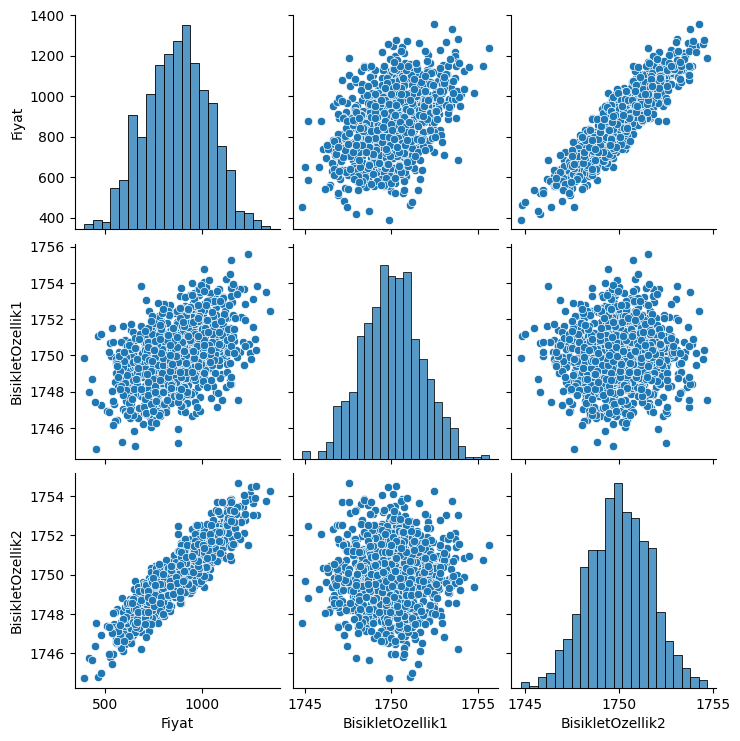

In [6]:
sbn.pairplot(dataFrame)

## Veriyi test/train olarak ayırmak

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
#train_test_split  dokumantasyon icin buraya bakabiliriz

In [9]:
#y = wx + b (w=agırlık,b=bias)  
#y --> label (tahmin etmeye çalıştıgımız deger)
y = dataFrame["Fiyat"].values

#x --> feature(özellik)
x = dataFrame[["BisikletOzellik1","BisikletOzellik2"]].values

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.33,random_state=15) #verilerin %33'ü test %67'si train olmak üzere ayrırırız random state verilerin rastgele bolunmesini kontrol eder 

In [10]:
x_train.shape

(670, 2)

In [11]:
x_test.shape

(330, 2)

In [12]:
y_train.shape

(670,)

In [13]:
y_test.shape

(330,)

## Scaling(ölçeklendirme)

özelliklerin değerlerini benzer ölçeklere getirme işlemi

In [14]:
from sklearn.preprocessing import MinMaxScaler

In [15]:
scaler = MinMaxScaler()

In [16]:
scaler.fit(x_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](2,)","[1755.61,1754.67]"
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](2,)","[1745. ,1744.99]"
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](2,)","[10.61, 9.67]"
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](2,)","[-164.44,-180.42]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,670
"scale_ scale_: ndarray of shape (n_features,)Per feature relative scaling of the data. Equivalent to``(max - min) / (X.max(axis=0) - X.min(axis=0))``.. versionadded:: 0.17 *scale_* attribute.","ndarray[float64](2,)","[0.09,0.1 ]"


In [17]:
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

In [18]:
x_train

array([[0.3177906 , 0.64341466],
       [0.61991638, 0.89583174],
       [0.53950097, 0.0980286 ],
       ...,
       [0.2352117 , 0.52644765],
       [0.7576794 , 0.19157421],
       [0.4292982 , 0.16530301]], shape=(670, 2))

In [19]:
import tensorflow as tf

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [21]:
model = Sequential()

model.add(Dense(4,activation="relu")) #4 nöronlu bir katman oluştur activation functions olarak relu kullan  
model.add(Dense(4,activation="relu"))
model.add(Dense(4,activation="relu"))

model.add(Dense(1)) #sonuc olarak tek bir sayi üreten output layer ekler 

"""
                 ┌── Nöron
                 ├── Nöron
Girdi → Dense(4) ├── Nöron
                 └── Nöron
                       ↓
                 Dense(4)
                       ↓
                 Dense(4)
                       ↓
                 Dense(1)
"""

model.compile(optimizer = "rmsprop",loss="mse")
#compile() modelin nasıl öğrendigi 
#optimizer="rmsprop" weights'ların nasıl güncelleneceğini belirler
#loss="mse" modelin ne kadar hata yaptığını ölçer (mse=mean squared error (ortalama kare hata))

In [ ]:
model.fit(x_train,y_train,epochs=250) #fit() modeli verilen eğitim verileri ile eğitir epochs=250 model eğitim verilerinden 250 kere geçer 

Epoch 1/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 795758.3750   
Epoch 2/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 795503.1875 
Epoch 3/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 795213.3125 
Epoch 4/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 794880.0625 
Epoch 5/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 794509.0625 
Epoch 6/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 794099.1250 
Epoch 7/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 793650.2500 
Epoch 8/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 793156.6250 
Epoch 9/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 792609.5000 
Epoch 10/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 791989.8750 
Epoch 11/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 791283.2500 
Epoch 12/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 790480.3750 
Epoch 13/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 789581.2500 
Epoch 14/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss

In [ ]:
loss = model.history.history["loss"] #loss değerleri gerçek veriler ile modelin tahminleri arasındaki farkın mse ile oluşturulmuş sayısal değeri loss yüksek değerlerden daha düşük değerlere gelmiş tahmin hatası azalmış 

<Axes: >

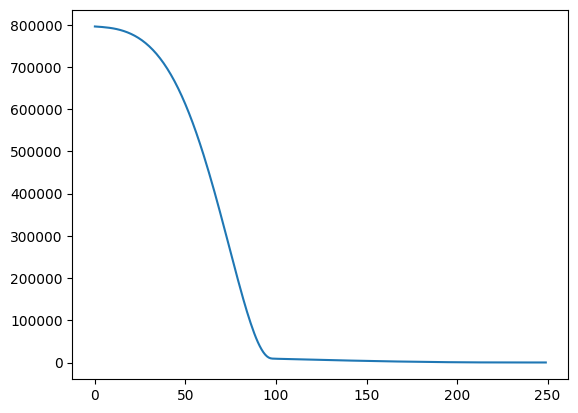

In [ ]:
sbn.lineplot(x=range(len(loss)),y=loss) #loss değerlerini grafik olarak çizer

In [32]:
trainLoss = model.evaluate(x_train,y_train,verbose=0)

In [30]:
testLoss = model.evaluate(x_test,y_test,verbose=0)

In [33]:
trainLoss

74.65975189208984

In [31]:
testLoss


73.90695190429688

In [35]:
testTahminleri = model.predict(x_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [38]:
testTahminleri

array([[1078.2524 ],
       [ 625.35583],
       [ 876.9717 ],
       [ 895.6111 ],
       [ 900.9529 ],
       [ 454.4088 ],
       [ 932.0674 ],
       [ 992.30426],
       [ 941.5852 ],
       [1017.4397 ],
       [ 752.1037 ],
       [ 918.36505],
       [ 948.6717 ],
       [1055.1287 ],
       [1121.3796 ],
       [ 683.196  ],
       [1127.7397 ],
       [ 653.0712 ],
       [1155.3704 ],
       [ 887.40094],
       [ 893.77704],
       [ 717.7939 ],
       [ 458.45877],
       [ 614.2289 ],
       [ 835.8599 ],
       [1091.4258 ],
       [ 715.3293 ],
       [ 758.3497 ],
       [ 874.7526 ],
       [ 772.0169 ],
       [ 453.62497],
       [ 784.06036],
       [ 729.7211 ],
       [ 648.64545],
       [ 887.811  ],
       [ 844.9582 ],
       [1036.2114 ],
       [1023.76605],
       [ 845.8543 ],
       [ 863.4245 ],
       [ 758.3752 ],
       [1175.0935 ],
       [1098.032  ],
       [1088.1887 ],
       [ 873.6695 ],
       [ 598.3032 ],
       [1146.625  ],
       [ 974.

In [40]:
tahminDataFrame = pd.DataFrame(y_test,columns=["Gerçek Y"])

In [41]:
tahminDataFrame

,Gerçek Y
0,1081.652164
1,622.675990
2,889.356810
3,902.826733
4,897.662404
...,...
325,1028.438035
326,789.934950
327,758.490486
328,1172.871659


In [44]:
testTahminleri = pd.Series(testTahminleri.reshape(330,))

In [45]:
testTahminleri

0      1078.252441
1       625.355835
2       876.971680
3       895.611084
4       900.952881
          ...     
325    1014.070862
326     792.343079
327     767.036377
328    1167.670410
329     804.426086
Length: 330, dtype: float32

In [47]:
tahminDataFrame = pd.concat([tahminDataFrame,testTahminleri],axis=1)

In [48]:
tahminDataFrame.columns = ["Gerçek Y","Tahmin Y"]

In [49]:
tahminDataFrame

,Gerçek Y,Tahmin Y
0,1081.652164,1078.252441
1,622.675990,625.355835
2,889.356810,876.971680
3,902.826733,895.611084
4,897.662404,900.952881
...,...,...
325,1028.438035,1014.070862
326,789.934950,792.343079
327,758.490486,767.036377
328,1172.871659,1167.670410


<Axes: xlabel='Gerçek Y', ylabel='Tahmin Y'>

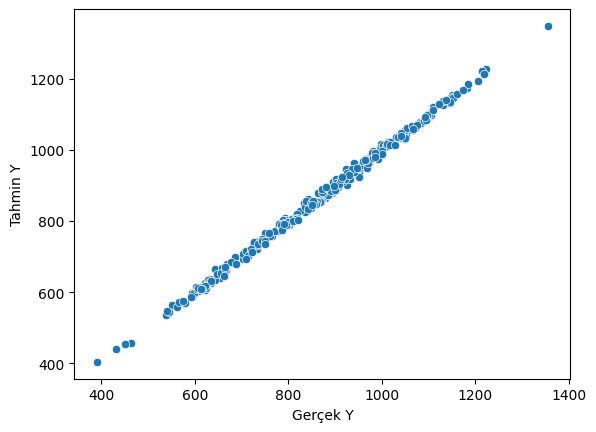

In [55]:
sbn.scatterplot(x="Gerçek Y", y="Tahmin Y", data=tahminDataFrame)

In [56]:
from sklearn.metrics import mean_absolute_error , mean_squared_error

In [58]:
mean_absolute_error(tahminDataFrame["Gerçek Y"],tahminDataFrame["Tahmin Y"]) #ortalama mutlak hata

6.872960561918795

In [ ]:
mean_squared_error(tahminDataFrame["Gerçek Y"],tahminDataFrame["Tahmin Y"]) #hataların karesi

73.90694622984842

In [65]:
dataFrame.describe()

,Fiyat,BisikletOzellik1,BisikletOzellik2
count,1000.000000,1000.000000,1000.000000
mean,872.677801,1750.024800,1749.964733
std,164.124504,1.704531,1.659578
min,390.856887,1744.852108,1744.742389
25%,757.795031,1748.831119,1748.803186
50%,879.168705,1750.017350,1750.003926
75%,988.612778,1751.115765,1751.129414
max,1355.213745,1755.613884,1754.666038


In [61]:
yeniBisikletOzellikleri = [[1760,1758]]
yeniBisikletOzellikleri = scaler.transform(yeniBisikletOzellikleri)


In [62]:
model.predict(yeniBisikletOzellikleri)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


array([[1980.7264]], dtype=float32)

In [66]:
from tensorflow.keras.models import load_model

In [ ]:
model.save("bisiklet_modeli.h5") #modeli .h5 formatında kayıt eder

In [ ]:
sonradanCagrilanModel = load_model("bisiklet_modeli.h5",compile=False) #modeli çağırmak icin kullanılır

In [72]:
sonradanCagrilanModel.predict(yeniBisikletOzellikleri)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


array([[1980.7264]], dtype=float32)